# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

**1)** In quantum mechanics, the Hamiltonian is an operator that corresponds to the total energy. It is often written as $\hat H = \hat T + \hat V$, where $\hat T$ is the operator corresponding to kinetic energy and $\hat V$ is the operator corresponding to potential energy. 

Sources:
- https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics)
- http://hyperphysics.phy-astr.gsu.edu/hbase/quantum/hamil.html
- https://phys.libretexts.org/Bookshelves/Classical_Mechanics/Variational_Principles_in_Classical_Mechanics_(Cline)/18%3A_The_Transition_to_Quantum_Physics/18.03%3A_Hamiltonian_in_Quantum_Theory

**2)** This is Hooke's law, $F = -\kappa(x-x_0)$, which gives a potential energy $V = \kappa(x-x_0)^2/2$. In this case, $x_0=0$.

**3)** An eigenstate is a state (wave function) of a quantum system such that when a specific operator $A$ is applied to it, the original wave function is just scaled by a constant. Mathematically, we can say that $A\psi(x)=a\psi(x)$, where $a$ is a constant called the eigenvalue.

Sources:
- https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Introductory_Quantum_Mechanics_(Fitzpatrick)/03%3A_Fundamentals_of_Quantum_Mechanics/3.08%3A_Eigenstates_and_Eigenvalues
- https://scienceinsights.org/what-is-an-eigenstate-definition-types-and-properties/
- https://quantumcomputing.stackexchange.com/questions/26000/what-are-the-eigenstates-of-an-operator

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.11599612236022949
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


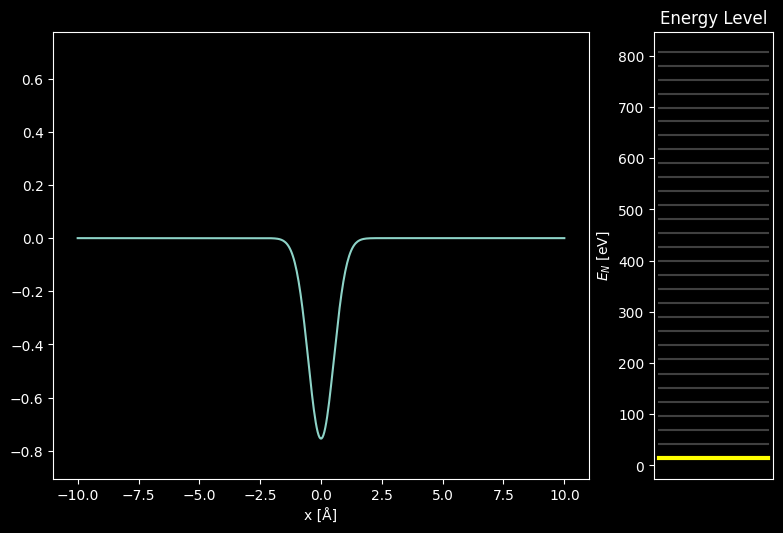

In [2]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

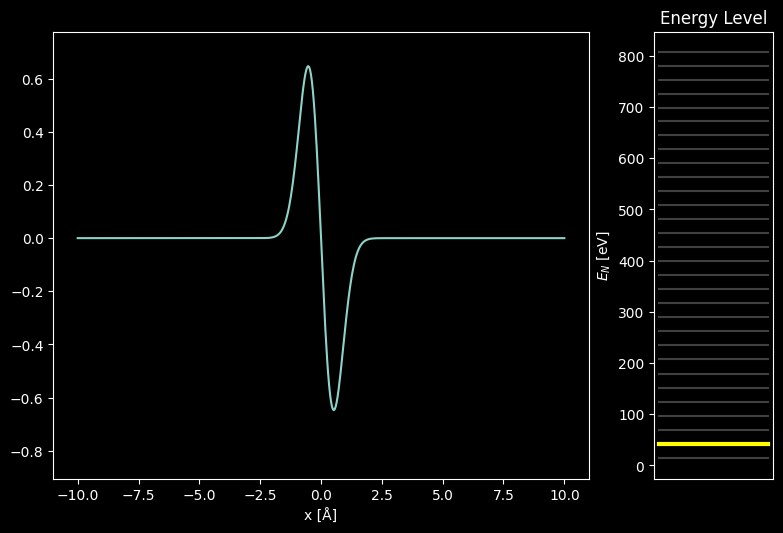

In [3]:
visualization.plot_eigenstate(1)

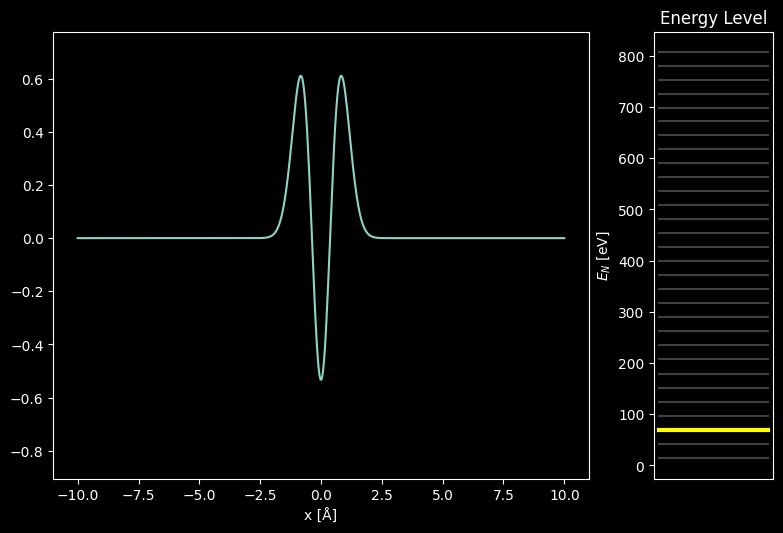

In [4]:
visualization.plot_eigenstate(2)

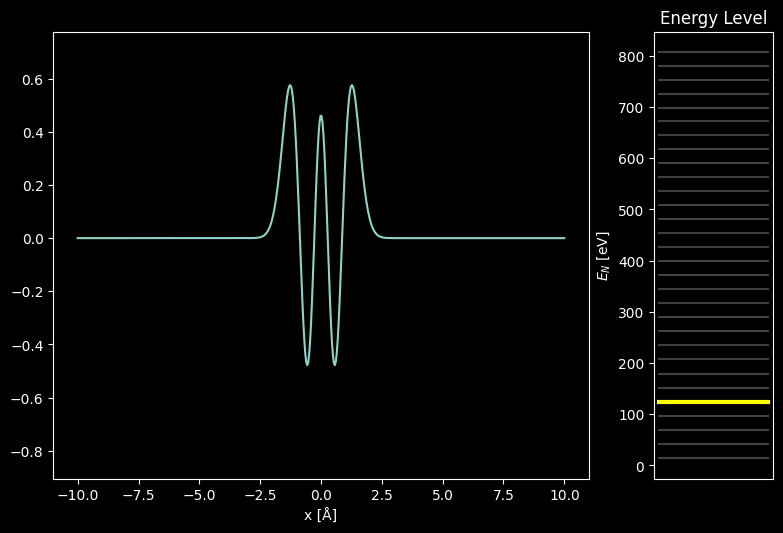

In [5]:
visualization.plot_eigenstate(4)

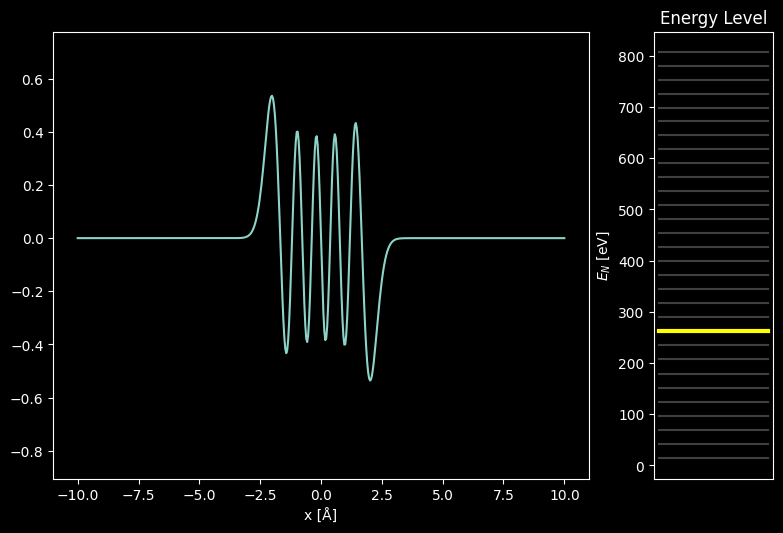

In [6]:
visualization.plot_eigenstate(9)

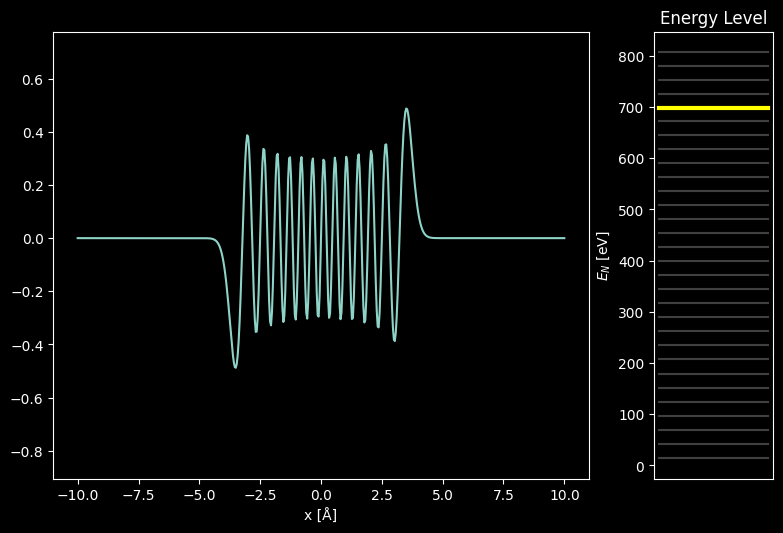

In [7]:
visualization.plot_eigenstate(25)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

**5)** The x-axis represents the spatial position $x$ of each point on the wave, measured in Angstroms.

**6)** These plots show wave functions $\psi(x)$. They cannot be probability functions because there are negative points on each plot, which would impossible for a probability function.

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

Computing...
Took 0.0052356719970703125
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


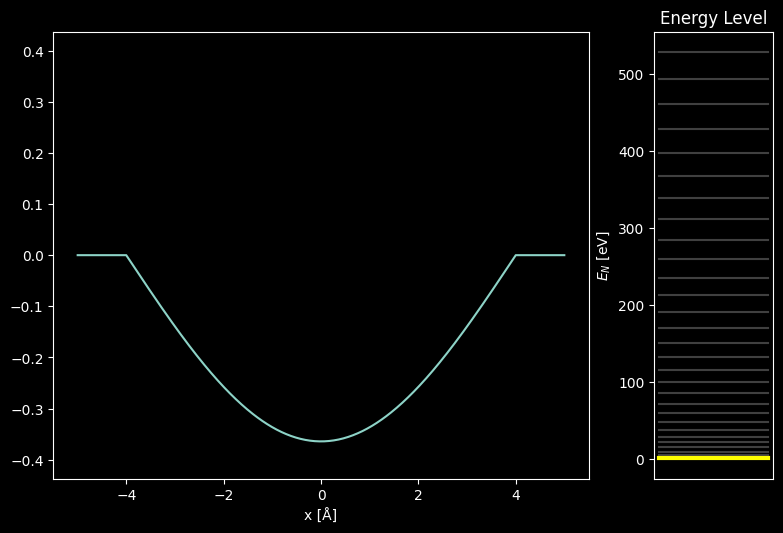

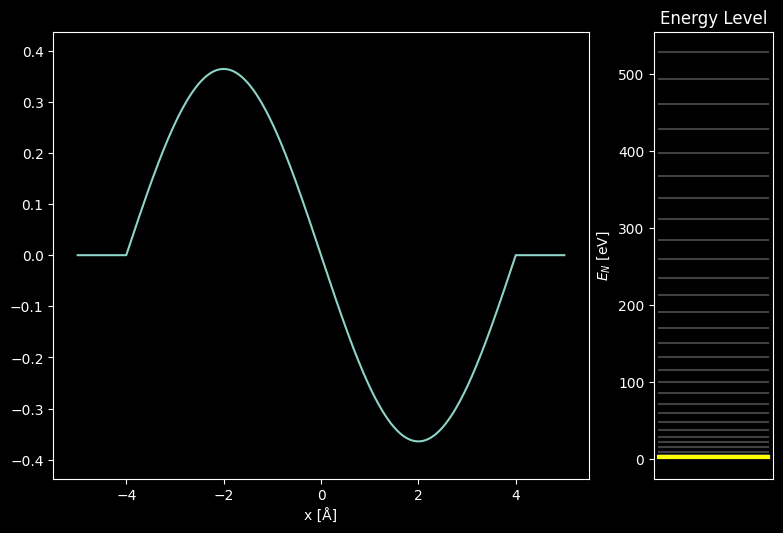

In [8]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

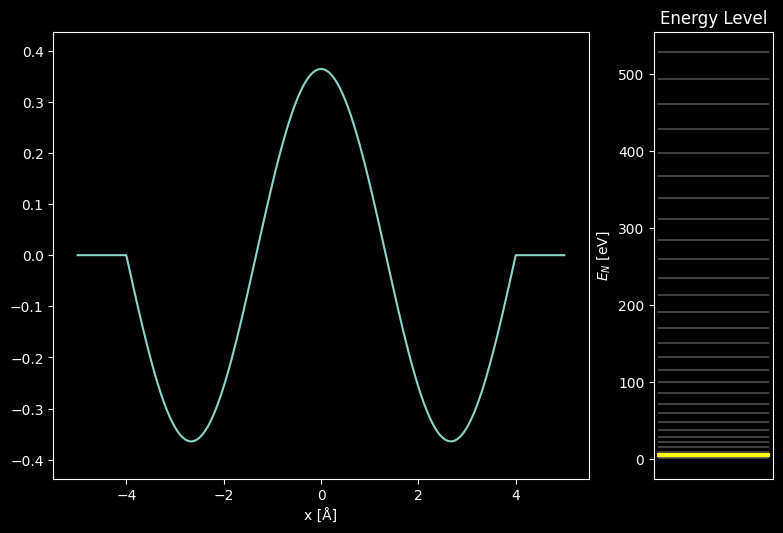

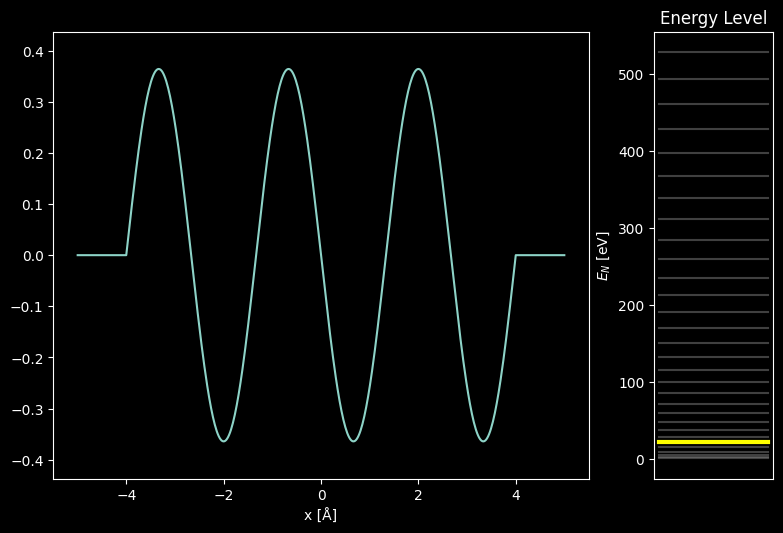

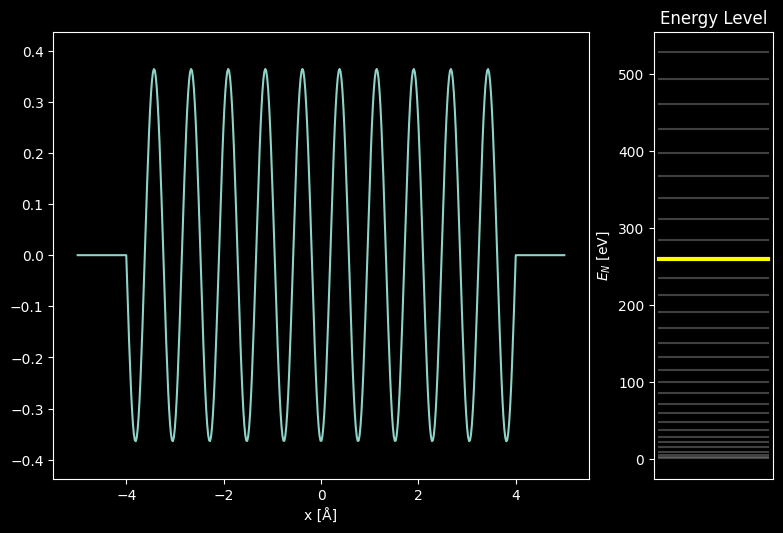

In [9]:
visualization_sw.plot_eigenstate(2)
visualization_sw.plot_eigenstate(5)
visualization_sw.plot_eigenstate(20)

**8)** The infinite square well eigenstates have $\psi(-4)=\psi(4)=0$ exactly at the walls of the well. This is because wave functions must be continuous, and $\psi(x)=0$ everywhere outside of the well, so the wave functions abruptly become 0 at the ends instead of decaying to 0 as $x \rightarrow \pm\infty$.

**9)** We can clearly see in each plot that the number of extrema is equal to $n+1$, where $n$ is the quantum number of the eigenstate.

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.010901689529418945
[  1.92595923   7.68488216  17.2139778   30.38330983  46.9261254
  66.16078878  83.52930884  85.74658757  88.70343151  96.74320831
 100.29576509 110.63265066 118.30245199 125.95003522 139.12563596
 148.52265713 159.7316978  174.78517356 186.61004786 200.50302732
 217.56704912 231.99060016 248.10654229 267.2858881  284.37098883
 302.51704392 323.79369635 343.58879016 363.72570471 386.99818178]


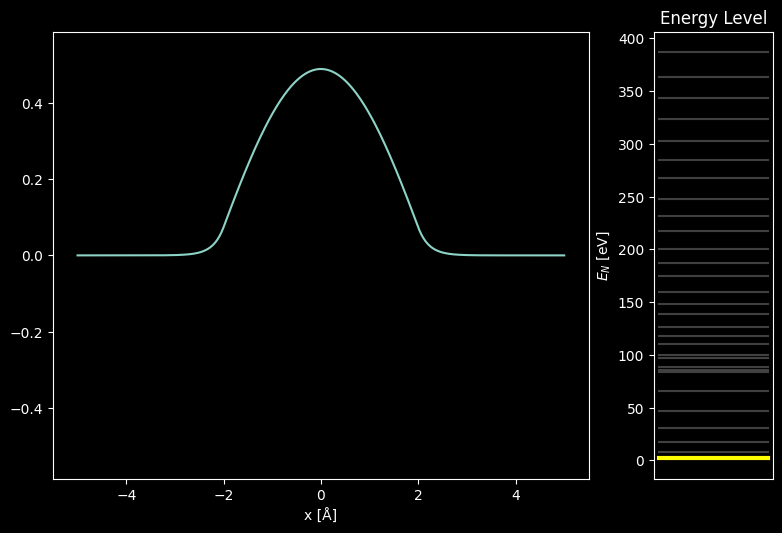

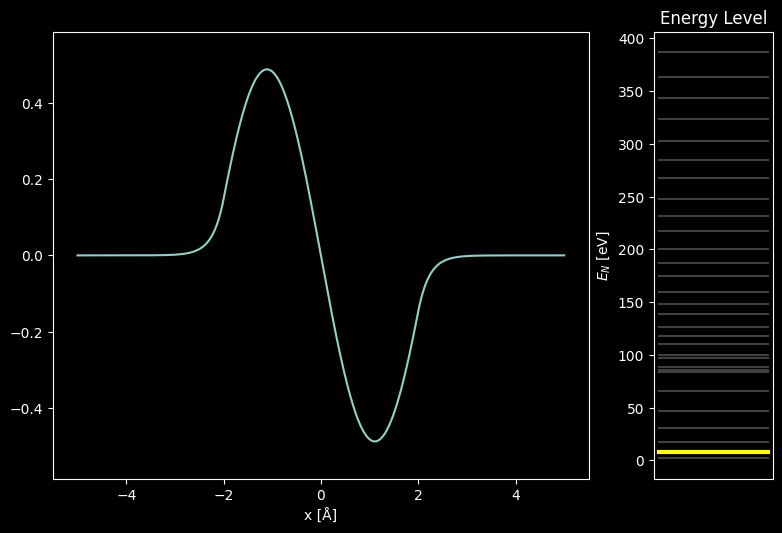

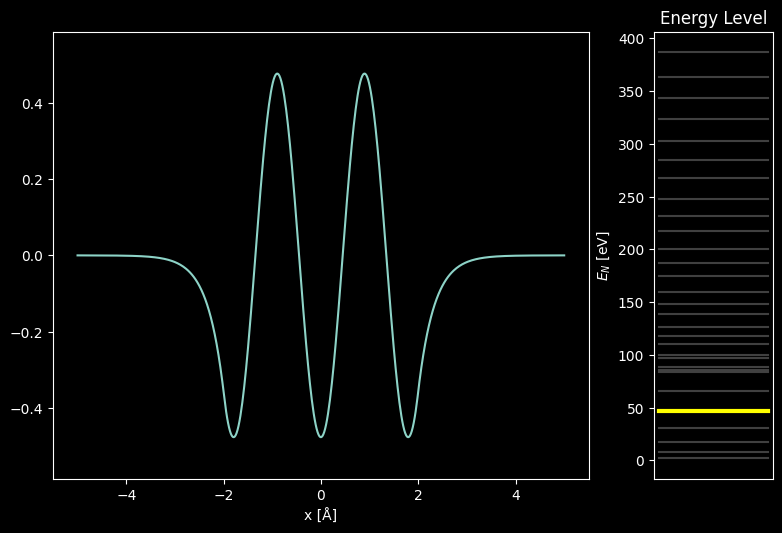

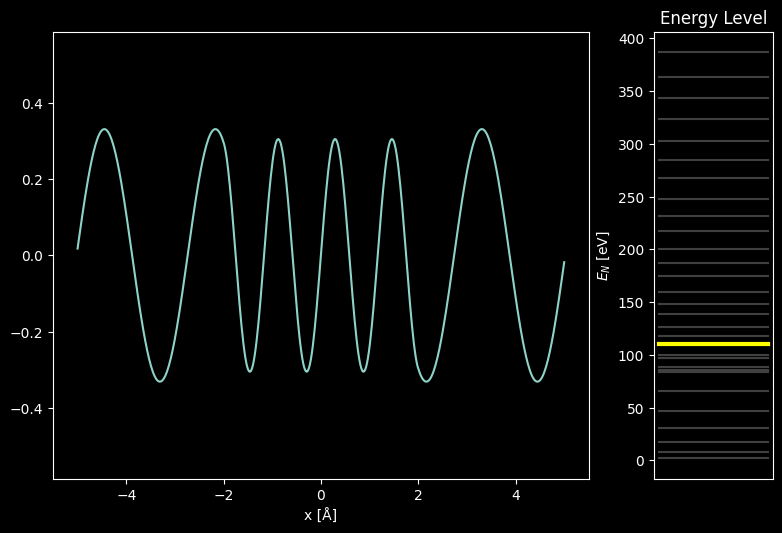

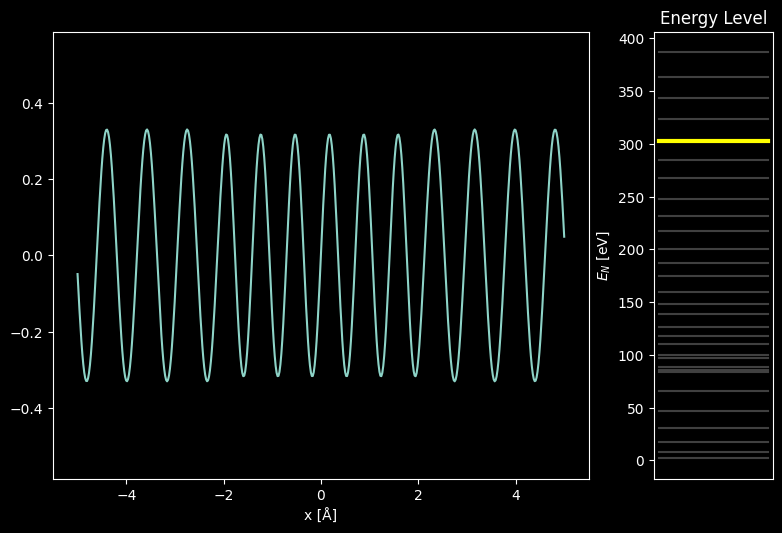

In [10]:
# 4 angstrom-wide finite square well with potential V_0 = 3
def finite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 2*Å
    potential[out_of_bounds] = 3
    return potential

# Define the Hamiltonian of the infinite square well
H_fsw = Hamiltonian(particles = SingleParticle(), potential = finite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_fsw = H_fsw.solve(max_states = 30)

print(eigenstates_fsw.energies)

# Visualize the infinite square well eigenstates
visualization_fsw = init_visualization(eigenstates_fsw)
visualization_fsw.plot_eigenstate(0)
visualization_fsw.plot_eigenstate(1)
visualization_fsw.plot_eigenstate(4)
visualization_fsw.plot_eigenstate(11)
visualization_fsw.plot_eigenstate(25)

**10)** The finite square well was defined to be 4 Angstroms wide, with a potential of 3 outside of the well.

**11)** Based on the plots, the particle should be able to get out of the well no matter its quantum number $n$. Unlike the infinite square well, the wave function is exponential outside of the well, not 0. So, the probability of a particle being outside of the well must also be nonzero (tunneling). Additionally, for higher quantum numbers, the particle has high enough energy to escape the well completely, observable in the plots for $n=11$ and $n=25$.

## 